# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]


# Figures Save Path

In [3]:
save_prefix = r"../../results/RLModel/"
import pathlib
try:
    pathlib.Path(save_prefix).mkdir(exist_ok=True)
except:
    print("Failed to create save dir...")

# Common Imports

In [4]:
import numpy as np
import pandas as pd

# Define Analysis Parameters

In [5]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures

In [7]:
# Analysis configuration.
#
# The models to evaluate are EvalSpec presets from model/aggregate.py: each is a
# (model_key, column_label) coordinate into the fits discovered on disk, so a
# figure never names a filename. See model/aggregate.py for the presets.
from .model.aggregate import (FIG1L_SPECS, SCALE_BOUND_SPECS, MLE_WEIGHT_SPECS,
                              DRIFT_RR_SPECS, CHI2_ONLY_RRQ_SPEC, MIN_NUM_TRIALS,
                              MIN_TRIALS_PER_SESS_RR,
                              IMAGING_ONLY_SUBJECTS)
from .model.aggregate import N_PSYCH_FITS as _N_PSYCH_FITS_DEFAULT

# --- Evaluations -----------------------------------------------------------
# Collection is the slow step, so it is separated from plotting:
#
#   NUM_EVALUATIONS      how many simulations per subject to COLLECT (seeds
#                        0..N-1). Expensive -- roughly (specs x subjects x N)
#                        x ~2.5s -- but cached to disk, so you pay it once.
#   PLOT_NUM_EVALUATIONS how many of those to actually USE when plotting; must
#                        be <= NUM_EVALUATIONS. Iteration i is seed i and the
#                        seeds are independent, so the first n is a valid
#                        subsample. Change this and re-run only the plot cell.
#   FORCE_RECOMPUTE      ignore the cache and re-simulate. The cache also
#                        invalidates itself when a fit file is newer than it,
#                        when the specs change, or when N_PSYCH_FITS changes.
NUM_EVALUATIONS = 1_00
PLOT_NUM_EVALUATIONS = NUM_EVALUATIONS
FORCE_RECOMPUTE = False

# Psychometric multi-starts per fit. This is ~64% of the cost of one
# evaluation, so lowering it is the cheapest way to speed up an exploratory
# pass -- but it changes the fitted values, so leave it at the default for
# any figure that goes in the paper. It is part of the cache key.
N_PSYCH_FITS = _N_PSYCH_FITS_DEFAULT   # lower (e.g. 5) for a fast pass

assert PLOT_NUM_EVALUATIONS <= NUM_EVALUATIONS, (
    f"PLOT_NUM_EVALUATIONS={PLOT_NUM_EVALUATIONS} > "
    f"NUM_EVALUATIONS={NUM_EVALUATIONS}: cannot plot more than we collected.")


# --- Subjects --------------------------------------------------------------
# GP4-23 / GP4-28 were fitted from data/RLModel/df_2p_missing.pkl so that
# model_neural_correlate.ipynb has model latents for every imaged animal. They
# are not part of the behavioral cohort -- they have no rows in df_behavior --
# so no figure in THIS notebook should show them. The exclusion is applied on
# the way OUT of each cached frame and is not part of any cache key, so editing
# this list never costs a re-collection.
EXCLUDE_SUBJECTS = IMAGING_ONLY_SUBJECTS

# --- Never re-collect by accident ------------------------------------------
# A full collection is an hours-long job. With REQUIRE_CACHE a cache that is
# merely stale (a fit pickle is newer, but every asked-for row is present) is
# used as-is with a loud warning, and a structural miss -- no cache, wrong
# specs, too few evaluations -- raises CacheUnavailable instead of quietly
# starting that job. Set it False when you actually do want to pay for a
# rebuild. It is mutually exclusive with FORCE_RECOMPUTE.
REQUIRE_CACHE = True

assert not (REQUIRE_CACHE and FORCE_RECOMPUTE), (
    "REQUIRE_CACHE forbids a collection and FORCE_RECOMPUTE demands one.")

# Load all mice data

In [8]:
from .model import compare
from .model.aggregate import select_subjects

# Loads + prepares the behavior dataframe exactly as the fitting code does
# (avg reward rate, size reduction, trial extension so every session has the
# same length, SessId/DVabs/Q/RewardRate columns).
df_behavior = compare.prepare_behavior_df()

# Drop the imaging-only animals here too, so the cells that read df_behavior
# directly (reward rate, prev-outcome quantiles, subject colours) see the same
# cohort as the cached model frames.
df_behavior = select_subjects(df_behavior, exclude=EXCLUDE_SUBJECTS,
                              what="behavior dataframe")

TODO: EarlyWithdrawal trials are not included, results may differ
Nullifying: 1,271/82,389 trials with calcStimulusTime > 4.8s (of which 73 are valid trials)
Calculate average reward rate (and create SessId column)...


Reduce dataframe size to speed up df operations...
Extend trials so all sessions have the same number of trials...


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model_runner.py:675: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(sess_li).reset_index(drop=True)


select_subjects: nothing to exclude for ['GP4-23', 'GP4-28'] — not in the behavior dataframe (present: ['Avgat1', 'Avgat2', 'Avgat3', 'BVGAT1', 'GP4-24', 'GP4-80', 'GP4-81', 'GP4-85', 'RDK_WT1', 'RDK_WT6', 'Rbp4_M2_1', 'WF10', 'WF11', 'vgat-40', 'vgat-94', 'vgat-95', 'vgat-96', 'vgat2.5', 'vgatchr2-sk', 'widefield_1']).


# Load Results

In [9]:
# Discover every saved fit on disk and index it by
# (model_key, column_label) -- the coordinate an EvalSpec addresses.
# model_key   = abstract model (drift alias + bias + noise + timing + asym)
# column_label= fitting criterion ("Chi2-Noise", "Chi2-Bound", "MLE", "MLE=1, Chi2=0.1", ...)
fits = compare.discover_fits()

Discovered 8 model(s), 162 subject×model combos.


In [10]:
# (getFitDict / runSubjectData used to live here. They are replaced by
#  model/aggregate.py's resolve_spec + model/compare.py's _compute_sim, which
#  route fitted params generically -- including fits where the frozen scale axis
#  (BOUND for a noise-scaled fit, NOISE_SIGMA for a scale-bound fit) is absent.)

## Ext. Fig. 5a-1st & 2nd columns

# Collect relevant data points

In [11]:
# (The reward-rate analysis constants moved to model/aggregate.py:
#  MIN_TRIALS_PER_SESS_RR, REWARD_RATE_NUM_PAST_TRIALS, REWARD_RATE_BY_SESS.)

In [12]:
from .model.aggregate import (load_or_collect_metrics, per_spec_frames,
                              rows_for_spec_from)

# One row per (model, subject, iteration), cached to disk under
# data/RLModel/metrics/. sim_cache collects the seed-0 simulation frame per
# model/subject for the per-subject figures below -- but ONLY on a real
# collection run: a cache hit does no simulation and leaves it empty.
sim_cache = {}
metrics_df = load_or_collect_metrics(
    fits, FIG1L_SPECS, df_behavior, cache_name="fig1l",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE, require_cache=REQUIRE_CACHE,
    exclude_subjects=EXCLUDE_SUBJECTS, sim_cache=sim_cache)
processed_df_dict = per_spec_frames(metrics_df)
display(metrics_df.head())

Restored 36 seed-0 simulation frame(s) from ..\..\data\RLModel\metrics\simcache_fig1l.pkl.
select_subjects: nothing to exclude for ['GP4-23', 'GP4-28'] — not in the fig1l metrics (present: ['Avgat1', 'Avgat3', 'GP4-85', 'RDK_WT1', 'Rbp4_M2_1', 'vgat-40', 'vgat-94', 'vgat-96', 'vgatchr2-sk']).


,SpecLabel,ModelKey,ColumnLabel,Name,Iteration,Seed,NumTrials,R2_WinLose,R2_PrevOutcomeCount,PrevOutcomeCurQuantileReal,...,PsychReal,PsychModel,R2_Psych,R2_Slow,R2_Fast,R2_Total,WinStayReal,WinStayModel,LoseSwitchReal,LoseSwitchModel
0,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,0,0,3169,0.722428,0.122985,15.5765,...,-0.388787,-0.000593,0.304247,0.975079,0.867398,1.842477,5.716688,0.449530,7.974684,10.249307
1,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,1,1,3169,0.823827,0.145773,15.5765,...,-0.388211,-0.055047,0.263350,0.990024,0.883697,1.873721,5.716688,1.913681,7.974684,9.256662
2,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,2,2,3169,0.713616,0.146776,15.5765,...,-0.403711,0.054731,0.269855,0.997207,0.846112,1.843319,5.716688,1.140385,7.974684,7.987220
3,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,3,3,3169,0.751006,0.135684,15.5765,...,-0.388523,-0.109015,0.249402,0.969611,0.870875,1.840486,5.716688,1.518260,7.974684,7.923497
4,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,4,4,3169,0.759715,0.241610,15.5765,...,-0.395362,0.159469,0.303989,0.978900,0.814848,1.793749,5.716688,1.327968,7.974684,8.625731


Key: Classic


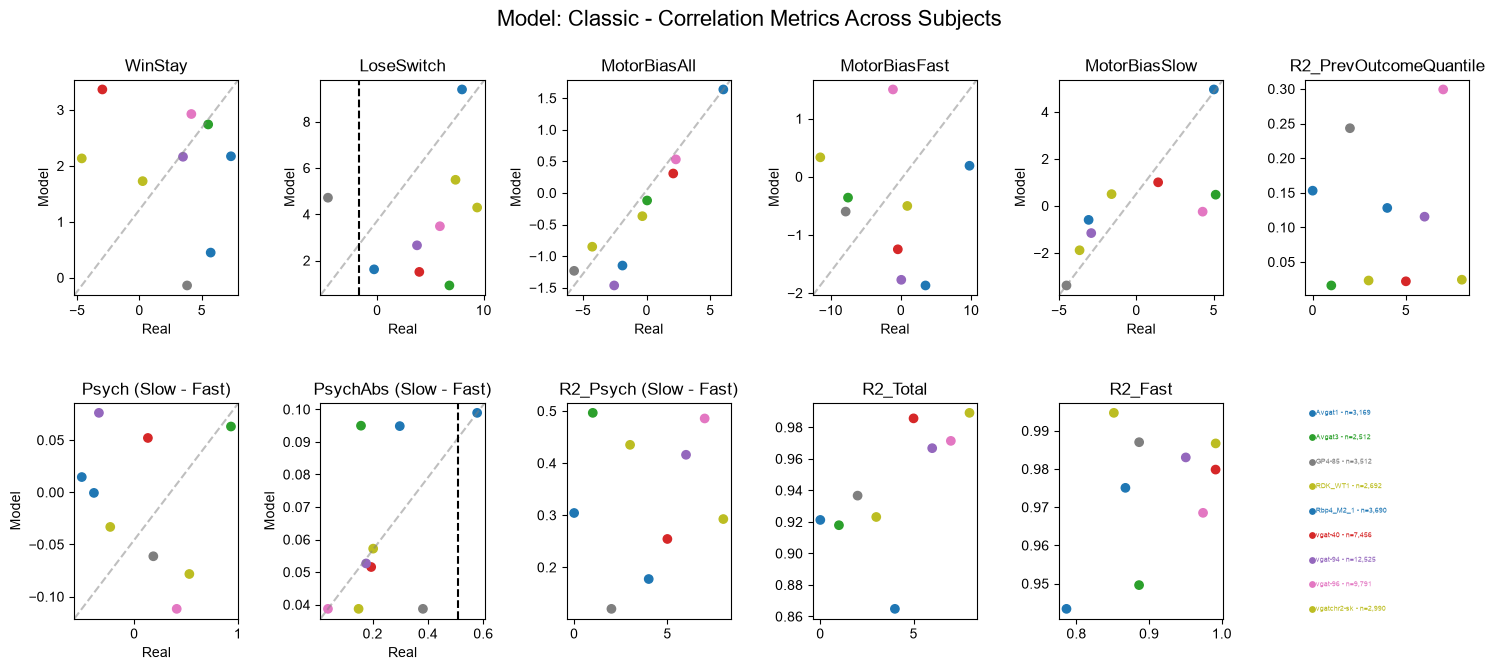

Key: Q-Val


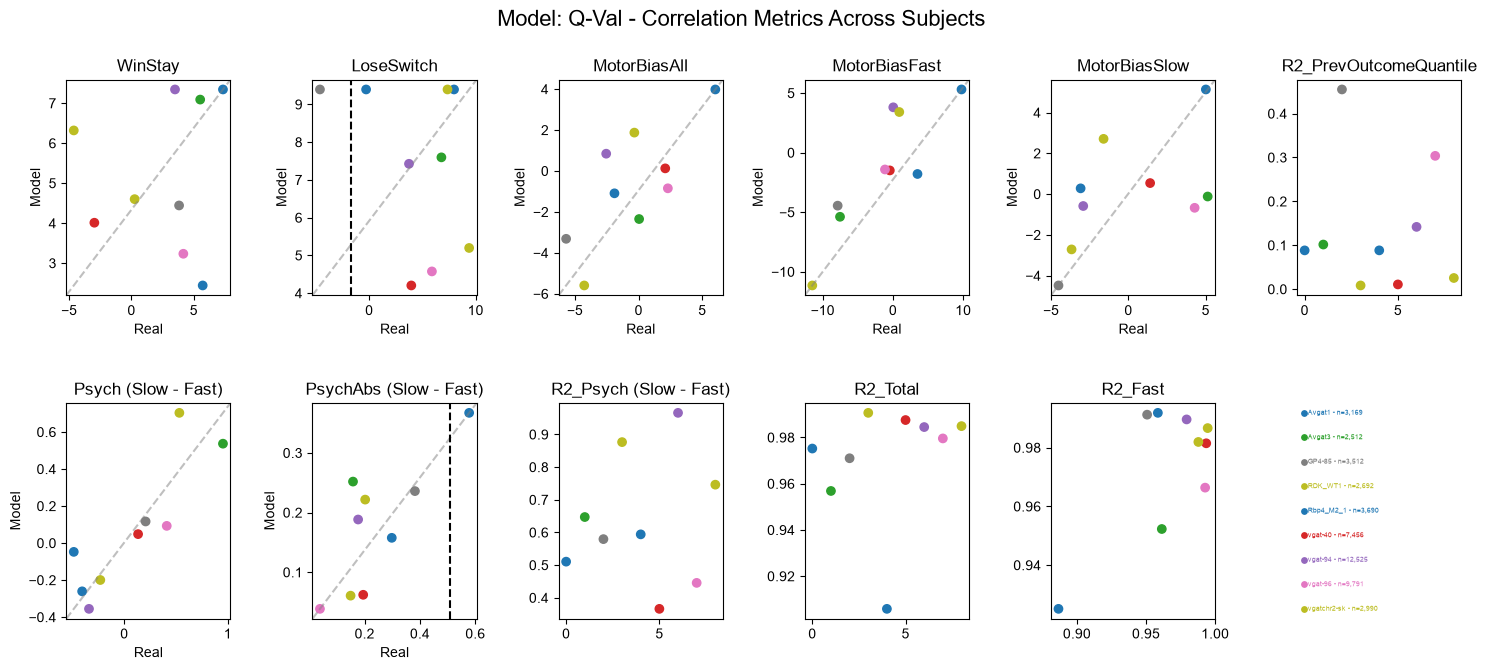

Key: RewardRate


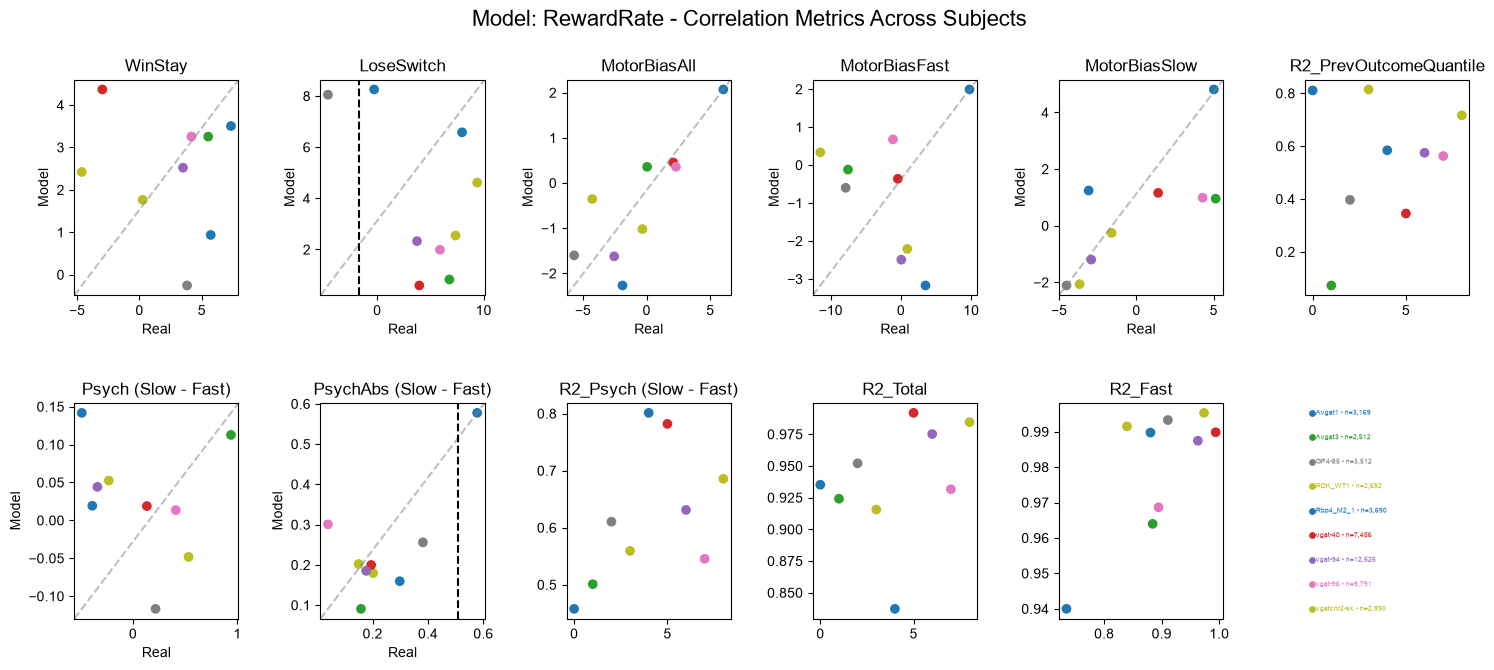

Key: RewardRate
+ Q-Val


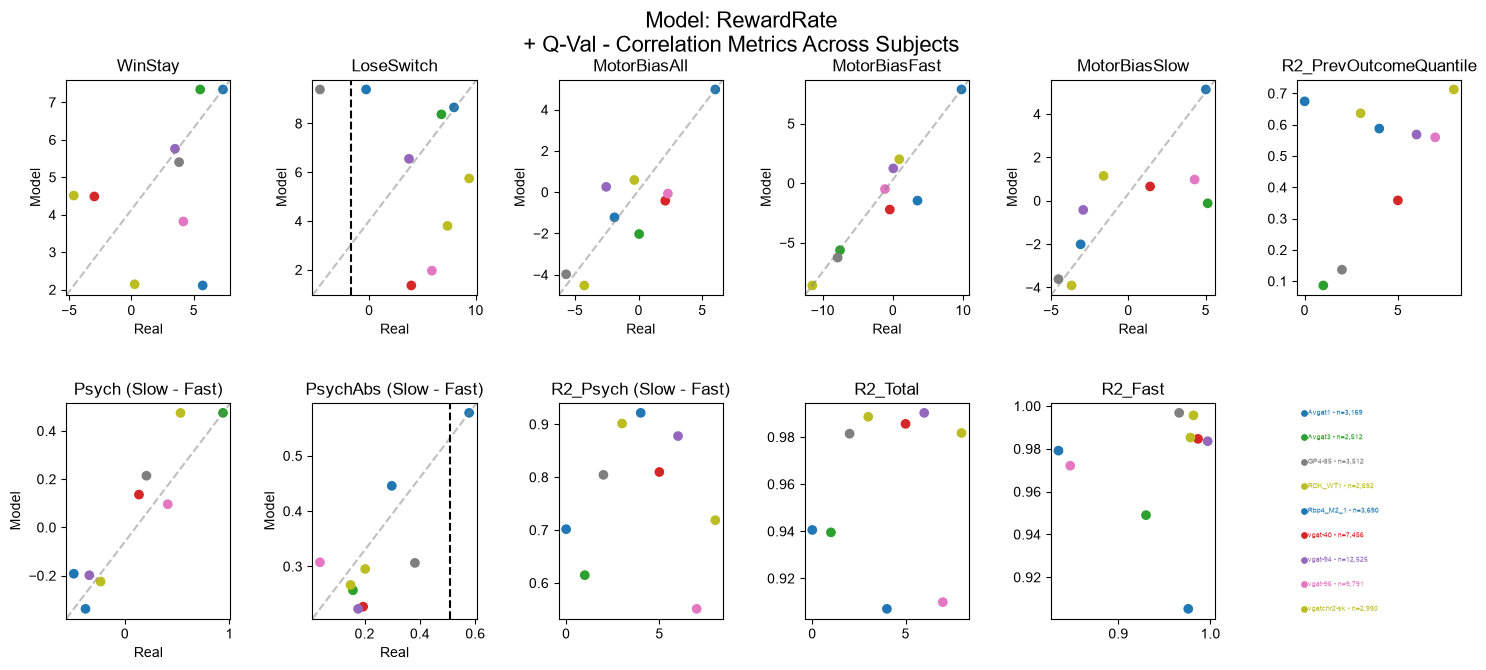

Saving: Model= Classic - Correlation Metrics Across Subjects


Saving: Model= Q-Val - Correlation Metrics Across Subjects


Saving: Model= RewardRate - Correlation Metrics Across Subjects


Saving: Model= RewardRate
+ Q-Val - Correlation Metrics Across Subjects


In [13]:
from .model.aggregate import safe_filename
from pathlib import Path


def plotCorrelations(analysis_df_dict, save_figs=False):
    subjects = df_behavior.Name.unique()
    subjects_colors = {subject: f"C{idx}"
                       for idx, subject in enumerate(subjects)}
    key_real_sim = ("WinStay", "LoseSwitch",
                    "MotorBiasAll", "MotorBiasFast", "MotorBiasSlow", "R2_PrevOutcomeQuantile",
                    "Psych", "PsychAbs", "R2_Psych", "R2_Total", "R2_Fast",)
    key_to_axs_li = {key: [] for key in key_real_sim}
    figs = []
    R2_TOTAL_MAX = 1 #.2
    for key, df in analysis_df_dict.items():
        print("Key:", key)
        model_name = key  # per_spec_frames keys by the EvalSpec label

        df = df.copy()
        df["Color"] = df.Name.apply(lambda x: subjects_colors[x])
        df["Marker"] = df.NumTrials.apply(
                lambda num_trials: "o" if num_trials >= MIN_NUM_TRIALS else "x")
        df = df[df.NumTrials >= MIN_NUM_TRIALS]
        # df = df[df.Name != "RDK_WT6"]

        fig, axs = plt.subplots(2, 6, figsize=(18, 7))
        fig.subplots_adjust(hspace=0.5, wspace=0.5)
        fig.suptitle(f"Model: {model_name} - Correlation Metrics Across Subjects",
                     fontsize=16)

        for ax, key in zip(axs.flatten(), key_real_sim):
            title = key if "Psych" not in key else f"{key} (Slow - Fast)"
            ax.set_title(title)
            if key in ("R2_Total", "R2_Psych", "R2_PrevOutcomeQuantile"):
                data = df[key].copy()
                if key == "R2_Total":
                    data /= 2
                # data = df["R2_Psych"].copy()
                # display(data)
                data = data.clip(0, R2_TOTAL_MAX)
                ax.scatter(df[key].index, data, c=df.Color)
                iqr_cols = []
            elif key in ("R2_Fast"):#, "R2_Slow"):
                for marker, marker_df in df.groupby("Marker"):
                    ax.scatter(marker_df["R2_Fast"], marker_df["R2_Slow"],
                               c=marker_df.Color, marker=marker)
                iqr_cols = []
            else:
                real_data, model_data = df[f"{key}Real"], df[f"{key}Model"]
                real_min, real_max = real_data.min(), real_data.max()
                above_limit = real_data > real_max
                below_limit = real_data < real_min
                within_limit = ~above_limit & ~below_limit
                model_data = model_data.clip(real_min, real_max)
                for marker, marker_df in df.groupby("Marker"):
                    marker_df_mask = df.index.isin(marker_df.index)
                    for mask, sub_marker in zip((within_limit, above_limit,  below_limit),
                                                (marker,       "^",          "v",)):
                        # if marker != "o":
                        #     print("Mask:", marker, "=", mask.sum())
                        ax.scatter(real_data[mask & marker_df_mask],
                                   model_data[mask & marker_df_mask],
                                   c=df.Color[mask & marker_df_mask],
                                   marker=sub_marker)
                iqr_cols = [f"{key}Real"]
                ax.set_xlabel("Real")
                ax.set_ylabel("Model")
                # Draw the 45 degree line
                ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--",
                        c="gray", alpha=0.5)

            # We are using zip behavior of looping only until the shortest list
            for iqr_col, axlineFn in zip(iqr_cols, (ax.axvline, ax.axhline)):
                # Get real data IQR
                q_25, q_75 = df[iqr_col].quantile((.25, .75))
                iqr = q_75 - q_25
                iqr_limits = (q_25 - 1.5*iqr, q_75 + 1.5*iqr)
                x_lims = ax.get_xlim()
                if x_lims[0] < iqr_limits[0]:
                    axlineFn(iqr_limits[0], c="black", ls="--")
                if x_lims[1] > iqr_limits[1]:
                    axlineFn(iqr_limits[1], c="black", ls="--")
            key_to_axs_li[key].append(ax)
        # In the very last ax, plot each subject name, color and number of trials
        names_ax = axs.flatten()[-1]
        names_ax.axis("off")
        widths = []
        for idx, (_, row) in enumerate(df.iterrows()):
            names_ax.scatter(0*2, idx, c=row.Color, marker=row.Marker, s=15)
            text = names_ax.text(2, idx, f"{row.Name} - n={row.NumTrials:,}",
                                 color=row.Color, fontsize=5, va="center")
            # Get text width
            text_bb = text.get_window_extent()
            text_width = text_bb.width
            widths.append(text_width)
        max_width = max(widths)
        names_ax.set_xlim(-3, max_width + 3)
        names_ax.invert_yaxis()
        plt.draw()
        plt.show()
        figs.append(fig)
    # plt.close(fig)


    # Re-allign all the axes to have the same limits
    for key, axs_li in key_to_axs_li.items():
        if key not in ("R2_Total", "R2_Psych", "R2_PrevOutcomeQuantile"):
            x_lims = [ax.get_xlim() for ax in axs_li]
            # if key == "R2_Fast":
            #     x_lims += [ax.get_ylim() for ax in axs_li]
            min_x = min([lim[0] for lim in x_lims])
            max_x = max([lim[1] for lim in x_lims])
            if key == "R2_Fast":
                y_lims = [ax.get_ylim() for ax in axs_li]
            else:
                y_lims = x_lims
            min_y = min([lim[0] for lim in y_lims])
            max_y = max([lim[1] for lim in y_lims])
            for ax in axs_li:
                ax.set_xlim(min_x, max_x)
                ax.set_ylim(min_y, max_y)
        else:
            # Set only common y
            y_lims = [ax.get_ylim() for ax in axs_li]
            min_y = min([lim[0] for lim in y_lims])
            max_y = max([lim[1] for lim in y_lims])
            for ax in axs_li:
                ax.set_ylim(min_y, max_y)

        for ax in axs_li:
            if "R2" not in key:
                ax.set_aspect("equal", "box")

            ax.spines[["top", "right"]].set_visible(False)
            if key == "R2_Fast":
                ax.set_title("R2_Fast vs R2_Slow")
                ax.set_xlabel("R2_Fast")
                ax.set_ylabel("R2_Slow")


    if save_figs:
        for fig in figs:
            label = fig._suptitle.get_text()
            label = label.replace(":", "=")
            print("Saving:", label)
            fp = Path(f"{save_prefix}/{safe_filename(label)}_by_fixed_subj_color.svg")
            fp.parent.mkdir(exist_ok=True)
            fig.savefig(fp, bbox_inches="tight")

plotCorrelations(processed_df_dict, save_figs=SAVE_FIGS)

# Save or view models fits for the different subjects

In [14]:
# One panel of this loop is published (Figures 2F and S4A), but the example's ID is
# not recorded -- so a paper-only run skips the loop rather than
# writing every subject. Pin the ID to bring the panel back.
from .model.plotter import plotPlots, PsychometricPlot, createFig
from .model.aggregate import safe_filename
from pathlib import Path


def plotFitDfs(sim_cache, save_figs=False, plt_show=None, plt_agg=False):
    """Per-subject (and optionally across-subject) model-fit panels."""
    if plt_show is None:
        plt_show = not save_figs
    assert plt_show or save_figs, "Either plt_show or save_figs must be True"

    for model_name, subjects_dict in sim_cache.items():
        df_li = []
        for subject, (loss, fitted_df, BOUND, include_Q,
                      include_RewardRate) in subjects_dict.items():
            df_li.append(fitted_df)
            fig, axs = createFig(is_small_fig_mode=False)
            plotPlots(fitted_df, axs=axs, is_small_fig_mode=False,
                      BOUND=BOUND, include_Q=include_Q,
                      include_RewardRate=include_RewardRate,
                      psych_plot=PsychometricPlot.SlowFast,
                      plot_bias_dir=False, t_dur=T_DUR, dt=DT)
            fig.suptitle(f"Subject: {subject}\nModel: {model_name}\n"
                         f"Loss: {loss:.4f}", y=1.1)
            if save_figs:
                subj_dir = Path(f"{save_prefix}figs//{subject}")
                subj_dir.parent.mkdir(exist_ok=True)
                subj_dir.mkdir(exist_ok=True)
                fig.savefig(f"{subj_dir}/{safe_filename(model_name)}.svg",
                            bbox_inches="tight")
            if plt_show:
                plt.show()
            else:
                plt.close(fig)

        if not plt_agg:
            continue
        fig, axs = createFig(is_small_fig_mode=False)
        fig.suptitle(f"All Subjects\nModel: {model_name}", y=1.05)
        plotPlots(pd.concat(df_li), axs=axs, is_small_fig_mode=False,
                  BOUND=BOUND, include_Q=include_Q,
                  include_RewardRate=include_RewardRate,
                  psych_plot=PsychometricPlot.SlowFast,
                  plot_bias_dir=False, t_dur=T_DUR, dt=DT)
        if save_figs:
            subj_dir = Path(f"{save_prefix}figs/all_subjects")
            subj_dir.parent.mkdir(exist_ok=True)
            subj_dir.mkdir(exist_ok=True)
            fig.savefig(f"{subj_dir}/{safe_filename(model_name)}.svg",
                            bbox_inches="tight")
        if plt_show:
            plt.show()
        else:
            plt.close(fig)


# Timing of the fits being plotted (all presets are 4.8s / dt=0.005).
T_DUR, DT = 4.8, 0.005
# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
_save_per_subject = SAVE_FIGS and not PAPER_FIGURES_ONLY
if PAPER_FIGURES_ONLY:
    print("Skipped: the published example's subject is not recorded, so a "
          "paper-only run cannot pick it out of the per-subject loop.")
elif not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    plotFitDfs(sim_cache, save_figs=_save_per_subject,
               plt_show=not _save_per_subject)


Clearing time: 0.02


Copy df time: 1.46


Psychometric: 2.76


Hists: 1.27
Dists: 0.02


Clearing time: 0.03


...

Hists: 1.16
Dists: 0.02


Clearing time: 0.02


Copy df time: 1.35


Psychometric: 2.69


Hists: 1.57
Dists: 0.04


# Plot Aggregates

## Fig. 1l

OOB RewardRateCorr - 'Classic':
	Avgat1: 0.4371868429241526
	Rbp4_M2_1: -0.16909192820522714
OOB RewardRateCorr - 'RewardRate':
	GP4-85: -0.7092520003004159
OOB RewardRateCorr - 'RewardRate\n+ Q-Val':
	GP4-85: -0.36359142632384933


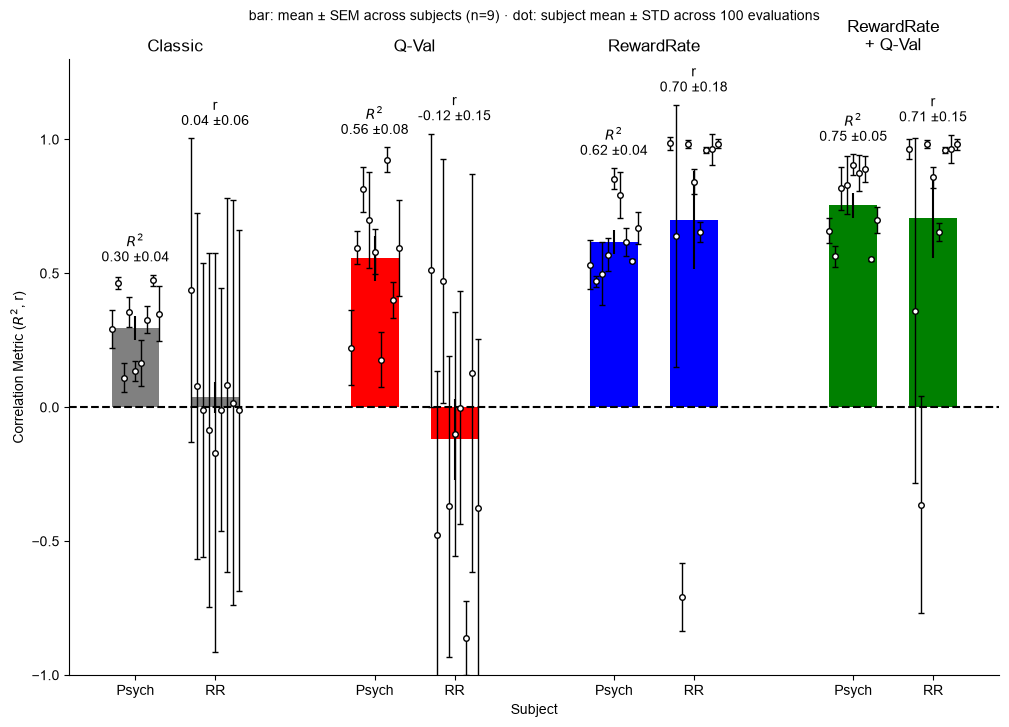

In [15]:
from .model.aggregate_plot import plot_aggregates

# Uses the first PLOT_NUM_EVALUATIONS of the collected iterations; re-running
# just this cell with a different value is cheap (no resimulation).
ax = plot_aggregates(metrics_df, FIG1L_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_bar.svg",
                      bbox_inches="tight", dpi=300)

# Model Comparison: reward-rate implementation

Reward-rate as a **noise gain** (fixed threshold) vs. as a **scaled bound** (fixed noise), each without and with Q-Val — all from their Chi² fits. The two members of each pair are the *same* abstract model fitted under a different criterion, so they share a `model_key` and differ only in `column_label`. A half-column of space separates the no-Q-Val pair from the +Q-Val pair.

select_subjects: nothing to exclude for ['GP4-23', 'GP4-28'] — not in the scale_bound metrics (present: ['Avgat1', 'Avgat3', 'GP4-85', 'RDK_WT1', 'Rbp4_M2_1', 'vgat-40', 'vgat-94', 'vgat-96', 'vgatchr2-sk']).
OOB RewardRateCorr - 'RewardRate (Noise)\nFixed Threshold':
	GP4-85: -0.7092520003004159
OOB RewardRateCorr - 'RewardRate (Scale-Bound)\nFixed Noise':
	GP4-85: -0.655241722275872
OOB RewardRateCorr - 'RewardRate (Noise)\nFixed Threshold + Q-Val':
	GP4-85: -0.36359142632384933
OOB RewardRateCorr - 'RewardRate (Scale-Bound)\nFixed Noise + Q-Val':
	Avgat3: -0.5272127723661275
	GP4-85: -0.6250226625510187


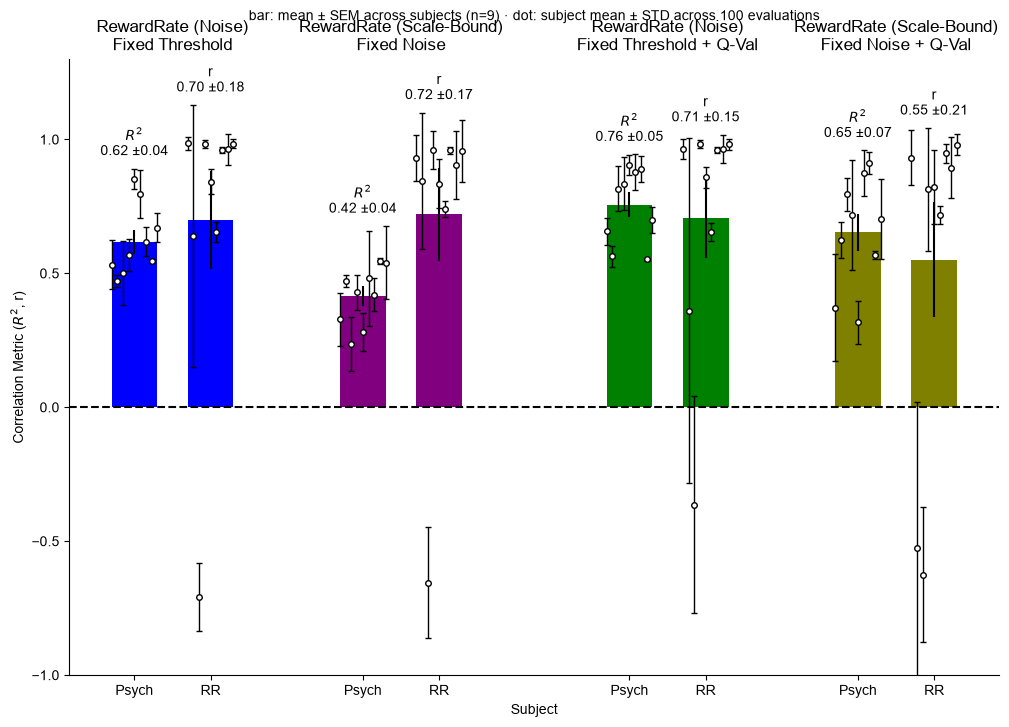

In [16]:
metrics_sb = load_or_collect_metrics(
    fits, SCALE_BOUND_SPECS, df_behavior, cache_name="scale_bound",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE, require_cache=REQUIRE_CACHE,
    exclude_subjects=EXCLUDE_SUBJECTS)
ax = plot_aggregates(metrics_sb, SCALE_BOUND_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_scale_bound.svg",
                      bbox_inches="tight", dpi=300)

# Model Comparison: reward-rate channel

Where the learned reward rate **r** acts, holding everything else fixed — all from their Chi² fits, without and with Q-Val. `RR` = RewardRate:

| Bar | Per-trial effect | Fit |
|---|---|---|
| `RR (Noise)` | `σ = S·r` | `Chi²-Noise` |
| `RR (Bound)` | `b = BOUND·(2−r)` | `Chi²-Bound` |
| `RR (Drift 2-r)` | `μ = V·DV·(2−r)` | `Chi²-Noise` |
| `RR (Drift 1+r)` | `μ = V·DV·(1+r)` | `Chi²-Noise` |

Noise and Bound are the *same* abstract model on two scale axes, so they share a `model_key` and differ only by criterion column. Each drift mapping is a different model (`--use-drift-rr`, `--drift-rr-map`), so each has its own `model_key` and is read from its fitted-noise / fixed-threshold fit — the same scale-axis convention as the `RR (Noise)` bar.

The two drift mappings run **opposite ways**: under `2-r` a high reward rate weakens the drift (slower, less accurate — the opposite *speed* direction from the noise and bound channels), under `1+r` it strengthens it (same direction as the other two). Having both bars is what makes that comparison readable.

Run the fits with, e.g.:

```
python -m code.rlmodel.model_runner --fit-mode chisq \
    --drift RewardRate --bias "Q-Val (Offset)" --use-drift-rr
python -m code.rlmodel.model_runner --fit-mode chisq \
    --drift RewardRate --bias "Q-Val (Offset)" --use-drift-rr --drift-rr-map 1+r
```


select_subjects: nothing to exclude for ['GP4-23', 'GP4-28'] — not in the drift_rr metrics (present: ['Avgat1', 'Avgat3', 'GP4-85', 'RDK_WT1', 'Rbp4_M2_1', 'vgat-40', 'vgat-94', 'vgat-96', 'vgatchr2-sk']).
OOB RewardRateCorr - 'RR (Noise)':
	GP4-85: -0.7092520003004159
OOB RewardRateCorr - 'RR (Bound)':
	GP4-85: -0.655241722275872
OOB RewardRateCorr - 'RR (Drift 2-r)':
	GP4-85: 0.5359647264352322
OOB RewardRateCorr - 'RR (Drift 1+r)':
	Avgat1: 0.7982145550073401
	GP4-85: -0.49051090067391917
OOB RewardRateCorr - 'RR (Noise)\n+ Q-Val':
	GP4-85: -0.36359142632384933
OOB RewardRateCorr - 'RR (Bound)\n+ Q-Val':
	Avgat3: -0.5272127723661275
	GP4-85: -0.6250226625510187
OOB R2_Psych - 'RR (Drift 2-r)\n+ Q-Val':
	Avgat1: 0.13820791614031058
	vgat-40: 0.14678412542032082
OOB RewardRateCorr - 'RR (Drift 2-r)\n+ Q-Val':
	GP4-85: 0.6145414548484276
OOB RewardRateCorr - 'RR (Drift 1+r)\n+ Q-Val':
	Avgat1: 0.750318193874453
	vgat-94: -0.43869730426722015


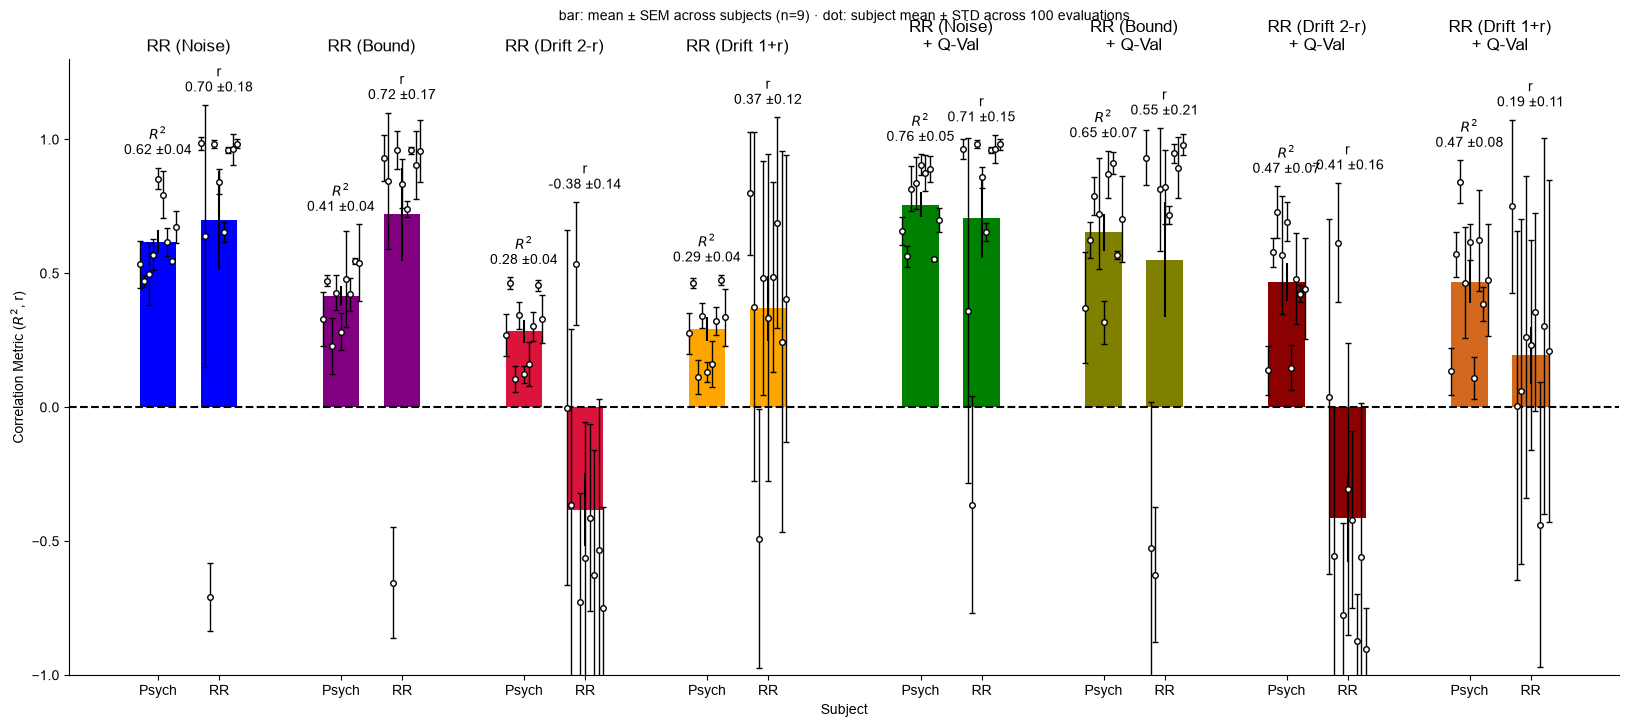

In [17]:
from .model.aggregate_plot import plot_aggregates

metrics_drift_rr = load_or_collect_metrics(
    fits, DRIFT_RR_SPECS, df_behavior, cache_name="drift_rr",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE, require_cache=REQUIRE_CACHE,
    exclude_subjects=EXCLUDE_SUBJECTS)
# Wider than the default (12, 8): eight bar groups, and at the default width
# the group labels above the bars run into each other.
ax = plot_aggregates(metrics_drift_rr, DRIFT_RR_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS, figsize=(20, 8))
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_drift_rr.svg",
                      bbox_inches="tight", dpi=300)


# Model Comparison: fitting criterion

One model — reward-rate (noise gain) + Q-Val — across fitting criteria: a **Chi²-only** reference first (its Chi²-Noise fit, reused from the Fig. 1l collection — not recomputed), then pure MLE (Chi² weight 0), joint MLE + Chi²=0.1, and joint MLE + Chi²=0.5. All share a `model_key`; only the `column_label` differs.

Each bar group's title carries a second, smaller line: the **pure-MLE loss per valid trial**, mean ± SEM across subjects. A fit pickle stores only the objective *it* minimized — a pure negative log-likelihood for the `MLE` column, a joint one for `MLE + Chi²=w`, a Chi² statistic for `Chi²-only` — so those stored values are not comparable to each other. The annotated number instead re-scores **every** column's fitted params under the *same* pure-MLE objective (`compare.mle_eval_result`, the same "MLE-Score" `model_compare`'s grid header shows), and divides by the trials that entered that sum, since an unnormalized log-likelihood is a sum and would otherwise mostly rank subjects by how many sessions they ran. The per-subject numbers behind it are in the frame the next cell displays.

select_subjects: nothing to exclude for ['GP4-23', 'GP4-28'] — not in the mle_weights metrics (present: ['Avgat1', 'Avgat3', 'GP4-85', 'RDK_WT1', 'Rbp4_M2_1', 'vgat-40', 'vgat-94', 'vgat-96', 'vgatchr2-sk']).
Excluded ['GP4-23', 'GP4-28'] from the mle_weights MLE losses.
Restricted the mle_weights MLE losses to 9 subject(s); dropped ['Avgat2', 'BVGAT1', 'GP4-24', 'GP4-80', 'GP4-81', 'RDK_WT6', 'WF10', 'WF11', 'vgat-95', 'vgat2.5', 'widefield_1'].
OOB RewardRateCorr - 'Chi²-only':
	GP4-85: -0.36359142632384933
OOB RewardRateCorr - 'MLE + Chi²=0.1':
	GP4-85: -0.588231217857627
OOB RewardRateCorr - 'MLE + Chi²=0.5':
	GP4-85: -0.48112248040282296


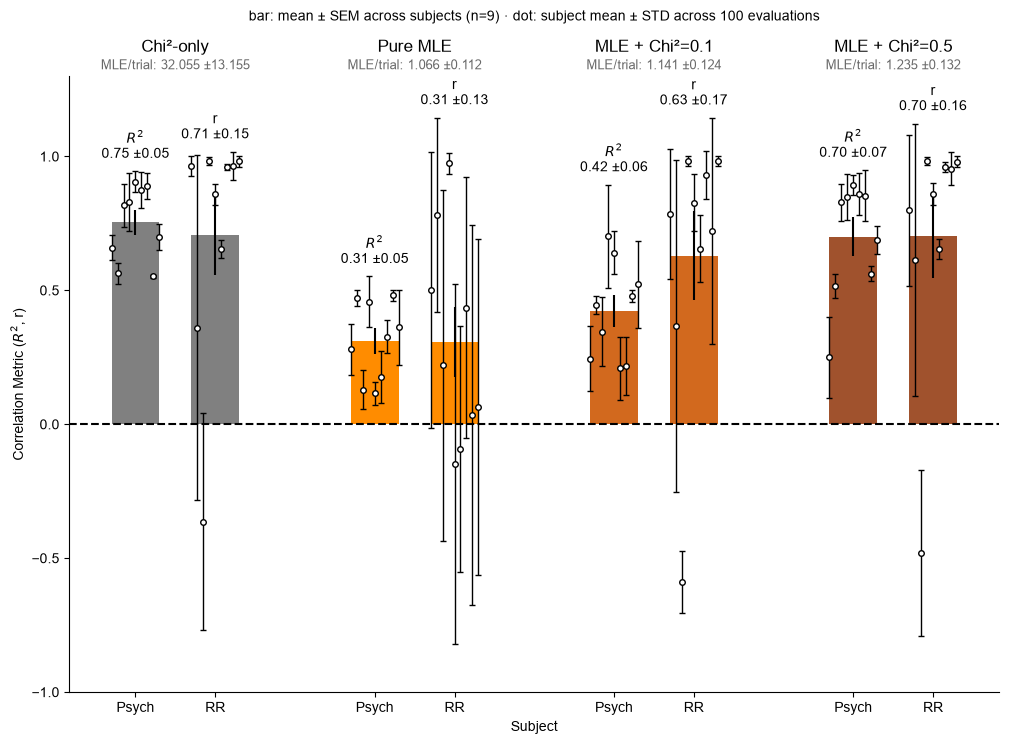

In [18]:
from .model.aggregate import load_or_collect_mle_losses
from .model.aggregate_plot import plot_aggregates

MLE_CRITERION_SPECS = [CHI2_ONLY_RRQ_SPEC, *MLE_WEIGHT_SPECS]

metrics_mle = load_or_collect_metrics(
    fits, MLE_WEIGHT_SPECS, df_behavior, cache_name="mle_weights",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE, require_cache=REQUIRE_CACHE,
    exclude_subjects=EXCLUDE_SUBJECTS)
# Prepend a Chi²-only reference column. Its fit is this same model's
# Chi²-Noise column, already collected for Fig. 1l -- borrow those rows
# from that frame (relabeled) instead of re-simulating them.
chi2_rows = rows_for_spec_from(metrics_df, CHI2_ONLY_RRQ_SPEC)
metrics_mle_full = pd.concat([chi2_rows, metrics_mle], ignore_index=True)

# Every column's fitted params re-scored under the SAME pure-MLE objective --
# the only likelihood comparable across these bars, since each column's own
# stored OptimRes.fun is whatever objective IT minimized. This is one
# deterministic pass per subject (no seeds, nothing to repeat), so unlike the
# metrics there is nothing to borrow from Fig. 1l: the Chi²-only column is
# scored here alongside the rest.
mle_losses_df = load_or_collect_mle_losses(
    fits, MLE_CRITERION_SPECS, df_behavior, cache_name="mle_weights",
    force_recompute=FORCE_RECOMPUTE, require_cache=REQUIRE_CACHE,
    exclude_subjects=EXCLUDE_SUBJECTS,
    # Scoring covers every subject in the fit files; the bars cover only
    # those that cleared MIN_NUM_TRIALS. Pin the annotation to the bars'
    # cohort or it averages a different, larger set of animals.
    subjects=metrics_mle_full.Name.unique())

ax = plot_aggregates(metrics_mle_full, MLE_CRITERION_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS,
                     mle_losses=mle_losses_df)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_mle_weights.svg",
                      bbox_inches="tight", dpi=300)

In [19]:
from .model.aggregate import mle_loss_summary

# The per-subject losses behind the annotation above.
#   NegLogLik          raw pure-MLE loss, summed over the subject's valid trials
#   NTrialsLoss        those valid trials -- the normalization denominator
#   NegLogLikPerTrial  NegLogLik / NTrialsLoss, the across-subject comparable one
#   FitObjective       the fit's own stored OptimRes.fun, for provenance: it
#                      should match NegLogLik for the "Pure MLE" bar only
display(mle_loss_summary(mle_losses_df))
display(mle_losses_df)
if SAVE_FIGS:   # same switch as the figures -- this table is the figure's data
    mle_losses_df.to_csv(f"{save_prefix}/mle_losses_by_criterion.csv",
                         index=False)

,Mean,SEM,NumSubjects
SpecLabel,,,
Chi²-only,32.055357,13.155375,9
Pure MLE,1.065699,0.111596,9
MLE + Chi²=0.1,1.140793,0.123733,9
MLE + Chi²=0.5,1.234901,0.132024,9


,SpecLabel,ModelKey,ColumnLabel,Name,NegLogLik,NTrialsLoss,NegLogLikPerTrial,FitObjective,Filename,Error,NTrialsTotal
0,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,Avgat1,416623.609751,3115,133.747547,259.106621,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,4862
2,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,Avgat3,108564.422007,2512,43.218321,118.036452,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,4096
9,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,GP4-85,68438.465573,3512,19.487035,53.828853,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,5850
10,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,RDK_WT1,28388.513400,2692,10.545510,77.618435,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,3584
12,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,Rbp4_M2_1,29919.245866,3690,8.108197,161.258304,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,7182
15,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,vgat-40,99951.268251,7456,13.405481,77.805374,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,13464
16,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,vgat-94,267233.038545,12525,21.335971,212.121794,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,23000
18,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,vgat-96,163547.423067,9791,16.703853,426.437207,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,18262
20,Chi²-only,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",Chi²-Noise,vgatchr2-sk,65619.426484,2990,21.946296,51.363145,chisq_NoiseGain-RewardRate_biasQ-Val (Offset)_...,None,7395
22,Pure MLE,"RewardRate|Q-Val (Offset)|Normal(0, 1)|4.8|0.0...",MLE,Avgat1,1999.391927,3115,0.641859,1999.315201,mle_NoiseGain-RewardRate_biasQ-Val (Offset)_No...,None,4862


# Plot aggregates where each subject has distinct color

OOB RewardRateCorr - Classic:
	RDK_WT1: 0.9998020683802334
OOB RewardRateCorr - RewardRate:
	GP4-85: -0.6023281512754833
OOB RewardRateCorr - RewardRate
+ Q-Val:
	GP4-85: 0.060161335640868285
OOB R2_WinLose - RewardRate:
	Avgat3: 0.27146038459955774
	vgat-94: 0.8004367972302305


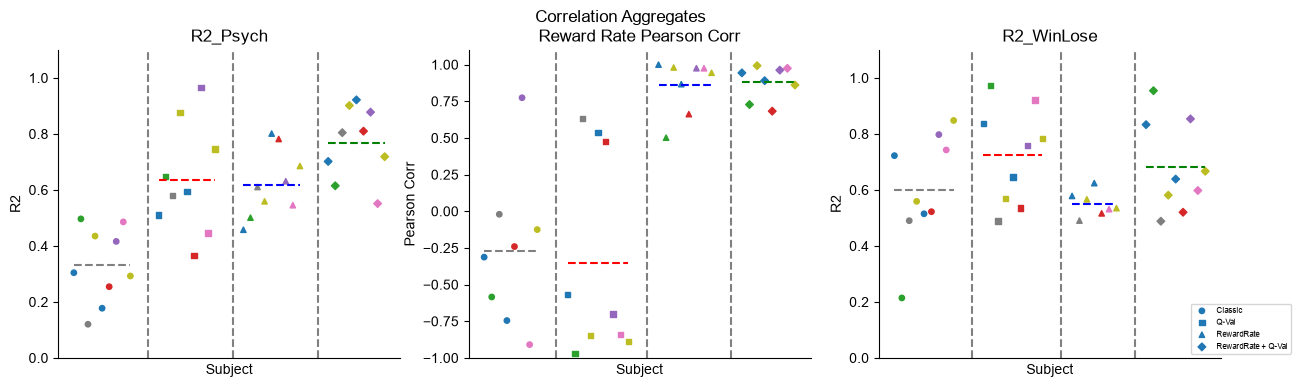

In [20]:
def _filterDF(df, min_num_trials, subjects_colors):
    df = df[df.NumTrials >= min_num_trials].copy()
    df["Color"] = df.Name.apply(lambda x: subjects_colors[x])
    return df


def plotAggregatesBySubjColor(analysis_df_dict, specs, save_figs=False):
    """Same aggregates as Fig. 1l, but one distinct colour per subject."""
    subjects = df_behavior.Name.unique()
    subjects_colors = {subject: f"C{idx}" for idx, subject in enumerate(subjects)}

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Correlation Aggregates")
    dfs_keys = ("R2_Psych", "RewardRateCorr", "R2_WinLose")
    markers = ("o", "s", "^", "D", "v", "P")

    for ax, key in zip(axs.flatten(), dfs_keys):
        ax.set_title("Reward Rate Pearson Corr"
                     if key == "RewardRateCorr" else key)
        offset_x = 0
        for spec, marker in zip(specs, markers):
            df = _filterDF(analysis_df_dict[spec.label], MIN_NUM_TRIALS,
                           subjects_colors)
            data = df[key]
            data_iqr = data.quantile([.25, .75])
            iqr = data_iqr[.75] - data_iqr[.25]
            OOB_mask = ((data < data_iqr[.25] - 1.5*iqr) |
                        (data > data_iqr[.75] + 1.5*iqr))
            if OOB_mask.any():
                print(f"OOB {key} - {spec.label}:")
                for idx, row in data[OOB_mask].items():
                    print(f"\t{df.Name.loc[idx]}: {row}")
            data = data[~OOB_mask]
            x_rng = np.arange(len(data))
            ax.plot(offset_x + x_rng, data.mean()*np.ones_like(x_rng),
                    c=spec.color, ls="--")
            ax.scatter(offset_x + x_rng, data, c=df[~OOB_mask].Color.values,
                       label=spec.label.replace("\n", " "), s=15, marker=marker)
            offset_x += len(x_rng) + 3
            if spec is not specs[-1]:
                ax.axvline(offset_x - 1.5, c="gray", ls="--")
        ax.set_xlabel("Subject")
        ax.set_ylabel("R2" if "R2" in key else "Pearson Corr")
        ax.set_ylim(-1 if key == "RewardRateCorr" else 0, 1.1)
        ax.set_xticks([])
        ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower left", bbox_to_anchor=(.9, 0), fontsize="xx-small",
              ncols=1)
    plt.draw()

    if save_figs:
        fig.savefig(f"{save_prefix}/aggregates_R2_subj_color.svg",
                    bbox_inches="tight")


plotAggregatesBySubjColor(processed_df_dict, FIG1L_SPECS, save_figs=SAVE_FIGS)

# Prev. Outcome by Animal"s session and Timeout Punishment

# Ext. Fig. 5a-right

In [21]:
# One panel of this loop is published (Extended Figure 5a right), but the example's ID is
# not recorded -- so a paper-only run skips the loop rather than
# writing every subject. Pin the ID to bring the panel back.
from .model.plotter import _plotPrevOutcomeQuantile


def loopModelSubjectsPlotPrevOutcomeCount(sim_cache, df_behavior,
                                          save_figs=False):
    model_names = list(sim_cache)
    for subject, subject_df in df_behavior.groupby("Name"):
        if len(subject_df[subject_df.valid]) < MIN_NUM_TRIALS:
            continue
        fig, axs = plt.subplots(nrows=len(model_names), ncols=1,
                                figsize=(8, 5*len(model_names)))
        for model_name, ax in zip(model_names, np.atleast_1d(axs).flatten()):
            if subject not in sim_cache[model_name]:
                continue
            loss, fitted_df, BOUND, include_Q, include_RewardRate = \
                                                sim_cache[model_name][subject]
            _plotPrevOutcomeQuantile(fitted_df, ax=ax, annotate_fast_slow=True)
            ax.set_title(f"Subject: {subject} - {model_name}\n" + ax.get_title())
        if save_figs:
            fp = pathlib.Path(f"{save_prefix}/StrategyByPrevCorrect/{subject}.svg")
            fp.parent.mkdir(exist_ok=True)
            fig.savefig(fp, bbox_inches="tight", dpi=300)
        plt.show()


# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
if not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    loopModelSubjectsPlotPrevOutcomeCount(sim_cache, df_behavior,
                                          save_figs=(SAVE_FIGS and not PAPER_FIGURES_ONLY))


# Plot Avg. Reward Rate

## Fig. 1k, Ext. Fig. 5a-3rd column

In [22]:
# One panel of this loop is published (Figure 2E), but the example's ID is
# not recorded -- so a paper-only run skips the loop rather than
# writing every subject. Pin the ID to bring the panel back.
from ..behavior.rewardrate import loopRewardRateAnalysis

def loopSubjectModels(processed_dict, df_behavior, subject_name=None,
                      save_figs=False):

    if subject_name is not None:
        df_behavior = df_behavior[df_behavior.Name == subject_name]

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    loop_kwargs = dict(
        plot_singles_on_all=False, plot_subjects=False, ax_all=ax,
        exclude_reward_rate_bins=[0], run_stats=False,
        min_trials_per_sess_rr=MIN_TRIALS_PER_SESS_RR,
        ax_all_used_timeout_time="All"
    )
    loopRewardRateAnalysis(df_behavior,
                           descrp="Behavior", #print_only_sim=True,
                           **loop_kwargs)
    for comb_str, comb_dict in processed_dict.items():
        # sim_cache is keyed by the EvalSpec label.
        # loss, fitted_df, BOUND, include_Q, include_RewardRate
        subjects_dict = {subject:fitted_df  for subject,
                        (loss, fitted_df, BOUND, include_Q, include_RewardRate) in comb_dict.items()
                        if subject_name is None or subject == subject_name
            }
        df_subjects = pd.concat(subjects_dict.values())
        loopRewardRateAnalysis(df_subjects, descrp=comb_str, print_only_sim=True,
                                **loop_kwargs)

    ax.axhline(0, color="gray", linestyle="--", alpha=0.3, zorder=-1)
    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_ylim(bottom=-0.6, top=1.5)
    ax.legend(loc="upper right", fontsize="small")

    ax.set_title("All Subjects" if subject_name is None else f"Subject: {subject_name}")
    if save_figs:
        label = f"subject_{subject_name}" if subject_name is not None else "all_subjects"
        fp = pathlib.Path(f"{save_prefix}/RewardRate/{label}.svg")
        fp.parent.mkdir(exist_ok=True)
        print("Saving:", label)
        fig.savefig(fp, bbox_inches="tight")
    plt.show()



def loopModels(processed_dict, df_behavior,
               plot_subjects=False, save_figs=False):
    df_behavior = df_behavior.groupby("Name").filter(
                                             lambda x: len(x) >= MIN_NUM_TRIALS)

    df_behavior["SessId"] = df_behavior.Name + "_" + \
                            df_behavior.Date.astype(str) + "_" + \
                            df_behavior.SessionNum.astype(str)
    loopSubjectModels(processed_dict, df_behavior=df_behavior,
                      subject_name=None,
                      save_figs=save_figs)
    if plot_subjects:
        for subject in df_behavior.Name.unique():
            loopSubjectModels(processed_dict, df_behavior=df_behavior,
                              subject_name=subject,
                              save_figs=save_figs)

# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
if not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    loopModels(sim_cache,
               df_behavior[df_behavior.valid].copy(),
               plot_subjects=True, save_figs=(SAVE_FIGS and not PAPER_FIGURES_ONLY))


Saving: all_subjects


Saving: subject_Avgat1


Saving: subject_Avgat3


Saving: subject_GP4-85


Saving: subject_RDK_WT1


Saving: subject_Rbp4_M2_1


Saving: subject_vgat-40


Saving: subject_vgat-94


Saving: subject_vgat-96


Saving: subject_vgatchr2-sk
